# **lab05 IA-02 — CNN EfficientNet con Scaled Dot Product Attention (SDPA)**  
**Reconocimiento y clasificación de residuos – carpeta `11` (5 clases)**

En este lab entrenamos, evaluamos y usamos en inferencia un modelo **EfficientNet-B0** con un bloque de **Scaled Dot Product Attention**. Todo corre en **Google Colab** con **CUDA/AMP**.  


## 1) Configuración global e hiperparámetros
**Qué define:**
- `parts = ['11']`, rutas de trabajo (`workRoot`).  
- `imgSize`, `batchSize`, `numWorkers`.  
- Épocas para **FROZEN** y (si se usa) **FINETUNE**.  
- `lrHead`, `weightDecay`, `labelSmoothing`, `dropoutRate`, `useBalancedSampling`.

**Salida esperada:** impresión de `workRoot`.

---

In [24]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# opcional: limpia copia previa
# !rm -rf "/content/MEGA_DATASET_LOCAL"

# crear destino local solo para la parte 11 y copiar
!mkdir -p "/content/MEGA_DATASET_LOCAL/11"
!rsync -ah --info=progress2 "/content/drive/MyDrive/MEGA_DATASET/11/" "/content/MEGA_DATASET_LOCAL/11/"

import torch, os, random, numpy as np
import torch.backends.cudnn as cudnn
from pathlib import Path

# apuntar el pipeline a la copia local
dataRoot = Path("/content/MEGA_DATASET_LOCAL")
print("dataRoot:", dataRoot)

# seeds y cuda
seed = 123
random.seed(seed); np.random.seed(seed)
torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print('device:', device)
print('cuda_version:', torch.version.cuda)
print('cudnn_ok:', cudnn.is_available())

# verificacion: listar clases dentro de 11
cls = sorted([p.name for p in (dataRoot/'11').iterdir() if p.is_dir()])
print('classes_in_11:', len(cls))
print(cls[:10], '...')


Mounted at /content/drive
              0 100%    0.00kB/s    0:00:00 (xfr#0, to-chk=0/6)
dataRoot: /content/MEGA_DATASET_LOCAL
device: cuda
cuda_version: 12.6
cudnn_ok: True
classes_in_11: 5
['barbijos', 'boligrafos', 'cds_dvds', 'restos_cigarros', 'tapas_botella'] ...


## 2) Transforms, Dataset & DataLoader (split estratificado)
**Qué incluye:**
- **Augmentations** de entrenamiento y normalización de validación.  
- `MappedImageDataset` para recorrer carpetas/clases.  
- **Balanced sampler** (`WeightedRandomSampler`) para equilibrio entre clases.  
- **Split estratificado por clase** (train/val) **sin fuga de datos**.  
- `makeLoadersForPart11()` devuelve `trainLoader`, `valLoader`, `classNames`.

**Salida esperada:** tamaños de dataset por split (si se imprime) y que los loaders funcionen.


In [29]:
from pathlib import Path

parts = ['11']  # solo entrenar carpeta 11

workRoot = Path('/content/drive/MyDrive/ResiduosSDPA_EfficientNet_only11')
workRoot.mkdir(parents=True, exist_ok=True)

# hiperparametros
imgSize = 224
batchSize = 64
numWorkers = max(2, os.cpu_count() or 2)

epochsFrozen = 4
epochsFinetune = 4

lrHead = 1e-3
lrBackbone = 2e-4
weightDecay = 1e-4

# regularizacion
labelSmoothing = 0.1
dropoutRate = 0.3
useBalancedSampling = True

print('workRoot:', workRoot)


workRoot: /content/drive/MyDrive/ResiduosSDPA_EfficientNet_only11


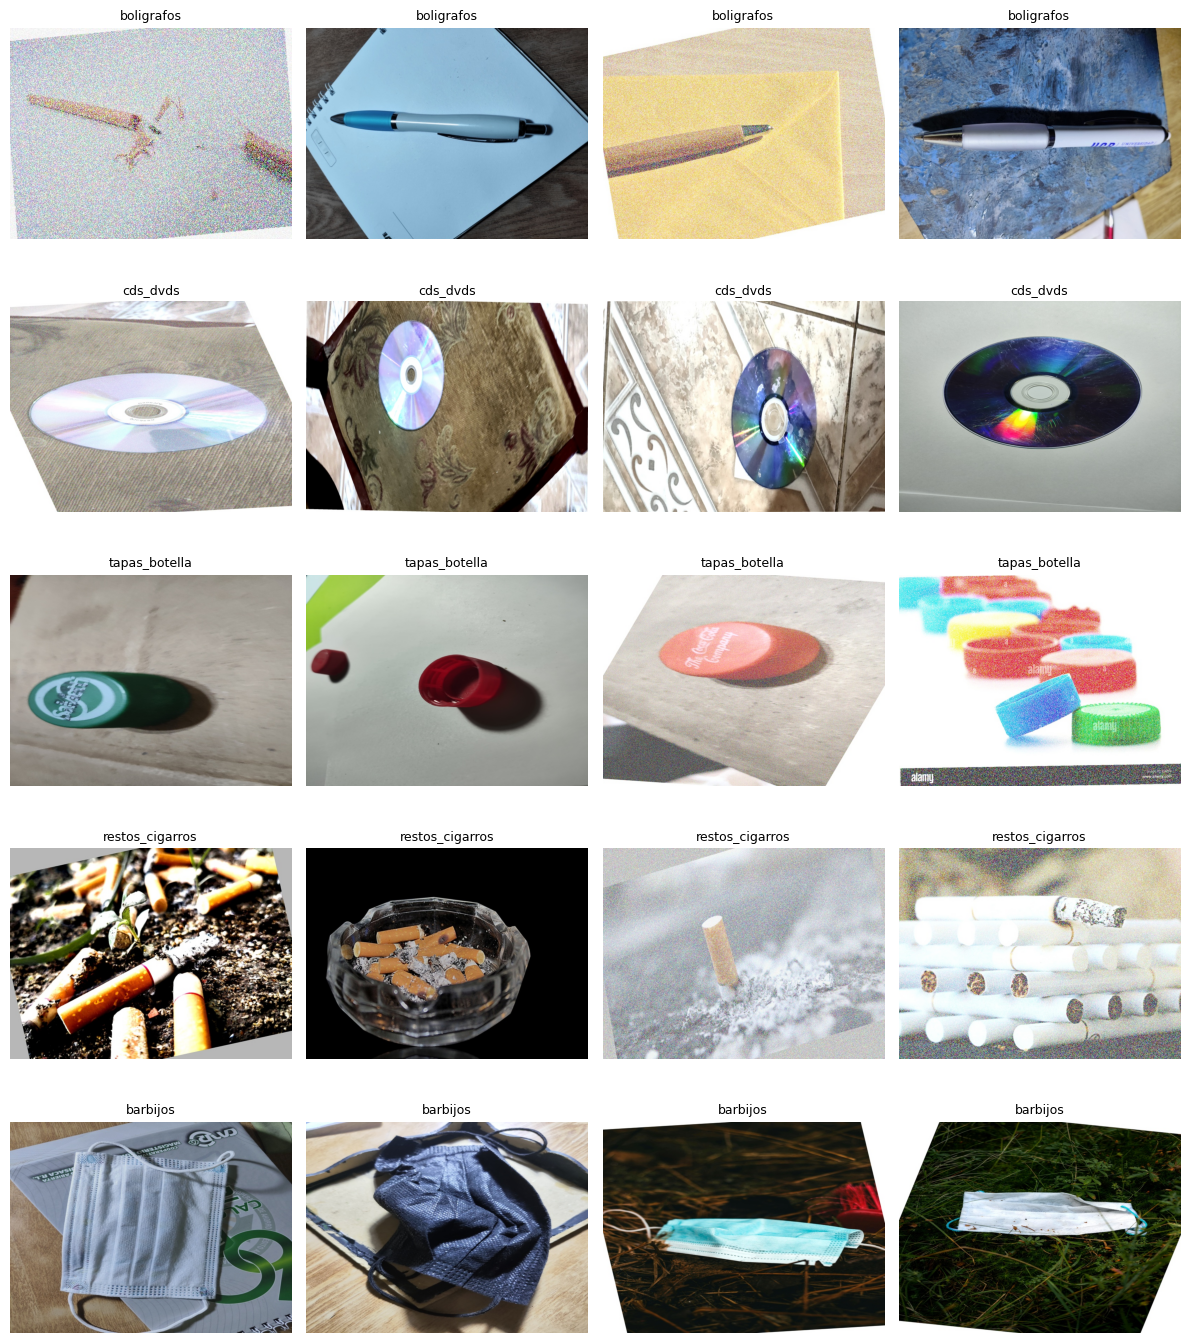

classes: 5
classes (first 5): ['boligrafos', 'cds_dvds', 'tapas_botella', 'restos_cigarros', 'barbijos']
samples_per_class: 4


In [48]:
# random preview from MEGA_DATASET_LOCAL/11: k images per class
import os, random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# config
dataRoot = Path("/content/MEGA_DATASET_LOCAL")  # ajusta si usas otra ruta
partPath = dataRoot / "11"
samplesPerClass = 4      # cuantas imagenes por clase quieres ver
shuffleClasses = True    # mezclar el orden de las clases en el grid
seed = 46               # fija para reproducibilidad (opcional)

random.seed(seed)

# helpers
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

def list_class_dirs(p: Path):
    return sorted([d for d in p.iterdir() if d.is_dir()])

def list_images(d: Path):
    files = []
    for root, _, fnames in os.walk(d):
        for fn in fnames:
            if os.path.splitext(fn)[1].lower() in IMG_EXTS:
                files.append(os.path.join(root, fn))
    return files

# get classes and pick random files
classDirs = list_class_dirs(partPath)
if shuffleClasses:
    random.shuffle(classDirs)

classNames = [d.name for d in classDirs]
chosen = []
for d in classDirs:
    imgs = list_images(d)
    if not imgs:
        chosen.append([])
        continue
    random.shuffle(imgs)
    chosen.append(imgs[:min(samplesPerClass, len(imgs))])

# figure layout
rows = len(classDirs)
cols = max(len(x) for x in chosen) if chosen else samplesPerClass
cols = max(cols, 1)

figW = max(6, 3 * cols)
figH = max(6, 2.8 * rows)
fig, axs = plt.subplots(rows, cols, figsize=(figW, figH))
if rows == 1 and cols == 1:
    axs = [[axs]]
elif rows == 1:
    axs = [axs]
elif cols == 1:
    axs = [[axs[r]] for r in range(rows)]

# plot
for r, (cname, files) in enumerate(zip(classNames, chosen)):
    for c in range(cols):
        ax = axs[r][c]
        ax.axis("off")
        if c < len(files):
            try:
                img = Image.open(files[c]).convert("RGB")
                ax.imshow(img)
                ax.set_title(f"{cname}", fontsize=9)
            except Exception as e:
                ax.text(0.5, 0.5, f"error\n{e}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

print("classes:", len(classNames))
print("classes (first 5):", classNames[:5])
print("samples_per_class:", samplesPerClass)


## 4) Scaled Dot Product Attention (SDPA)
- **Train (augmentations):**  
  `RandomResizedCrop(224)`, `HorizontalFlip`, `RandomRotation(±10°)`,  
  `ColorJitter` suave, `RandomGrayscale(p=0.05)`, **Normalización** (ImageNet),  
  y **RandomErasing(p=0.25)** tipo cutout.
- **Validación/Inferencia:** `Resize→CenterCrop(224)`, **Normalización**.


In [30]:
import torchvision.transforms as T
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from PIL import Image
import os, random
from collections import Counter
from typing import List, Dict

meanEff = [0.485, 0.456, 0.406]
stdEff  = [0.229, 0.224, 0.225]

trainTf = T.Compose([
    T.RandomResizedCrop(imgSize, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
    T.RandomGrayscale(p=0.05),
    T.ToTensor(),
    T.Normalize(meanEff, stdEff),
    T.RandomErasing(p=0.25, scale=(0.02, 0.10), ratio=(0.3, 3.3), inplace=True),
])

valTf = T.Compose([
    T.Resize(int(imgSize*1.15)),
    T.CenterCrop(imgSize),
    T.ToTensor(),
    T.Normalize(meanEff, stdEff),
])

def listClassDirs(partPath: Path) -> List[Path]:
    return sorted([p for p in partPath.iterdir() if p.is_dir()])

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

class MappedImageDataset(Dataset):
    def __init__(self, classDirs: List[Path], classToIdx: Dict[str,int], transform=None):
        self.transform = transform
        self.classToIdx = classToIdx
        self.files, self.labels = [], []
        dirs = sorted(classDirs, key=lambda p: p.name)
        for d in dirs:
            y = classToIdx[d.name]
            for root, _, fnames in os.walk(d):
                for fn in fnames:
                    if os.path.splitext(fn)[1].lower() in IMG_EXTS:
                        self.files.append(os.path.join(root, fn))
                        self.labels.append(y)
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img, self.labels[idx]

def makeBalancedSampler(labels):
    counts = Counter(labels)
    total = float(sum(counts.values()))
    classWeight = {c: total/(len(counts)*counts[c]) for c in counts}
    weights = [classWeight[y] for y in labels]
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

def makeLoadersForPart11():
    partPath = dataRoot / '11'
    classDirs = listClassDirs(partPath)
    classNames = [d.name for d in classDirs]
    classToIdx = {name:i for i, name in enumerate(classNames)}

    dsTrain = MappedImageDataset(classDirs, classToIdx, transform=trainTf)
    dsVal   = MappedImageDataset(classDirs, classToIdx, transform=valTf)

    sampler = None
    if useBalancedSampling:
        sampler = makeBalancedSampler(dsTrain.labels)

    # kwargs seguros para num_workers
    trainKw = dict(batch_size=batchSize, shuffle=(sampler is None),
                   num_workers=numWorkers, pin_memory=True, drop_last=True)
    valKw   = dict(batch_size=batchSize, shuffle=False,
                   num_workers=numWorkers, pin_memory=True)
    if numWorkers > 0:
        trainKw.update(dict(persistent_workers=True, prefetch_factor=2))
        valKw.update(dict(persistent_workers=True, prefetch_factor=2))

    trainLoader = DataLoader(dsTrain, sampler=sampler, **trainKw)
    valLoader   = DataLoader(dsVal, **valKw)
    return trainLoader, valLoader, classNames, classToIdx


## 3) Modelo: EfficientNet-B0 + Scaled Dot Product Attention (SDPA)
**Arquitectura:**
- Se usa `efficientnet_b0` como **backbone** (con pesos ImageNet).  
- Se extrae el *feature map*, se reduce a 7×7 → **49 tokens** (N).  
- **SDPA multi-head** sobre la secuencia (Q,K,V; escala \(1/\sqrt{d_k}\)).  
- Promedio sobre tokens → **LayerNorm** → **Dropout(s)** → **Linear** (clasificador).  
- Opción de **congelar** el backbone y método `unfreeze()`.

**Salida esperada:** clase `EffNetSDPA` lista para instanciarse.


In [31]:
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch, math

class ScaledDotProductAttention(nn.Module):
    def __init__(self, dModel, nHeads=4, pDrop=0.1):
        super().__init__()
        self.nHeads = nHeads
        self.dk = dModel // nHeads
        self.wq = nn.Linear(dModel, dModel, bias=False)
        self.wk = nn.Linear(dModel, dModel, bias=False)
        self.wv = nn.Linear(dModel, dModel, bias=False)
        self.wo = nn.Linear(dModel, dModel, bias=False)
        self.drop = nn.Dropout(pDrop)
    def forward(self, x):
        B, N, C = x.shape
        q = self.wq(x).view(B, N, self.nHeads, self.dk).transpose(1,2)
        k = self.wk(x).view(B, N, self.nHeads, self.dk).transpose(1,2)
        v = self.wv(x).view(B, N, self.nHeads, self.dk).transpose(1,2)
        scores = torch.matmul(q, k.transpose(-2,-1)) / math.sqrt(self.dk)
        attn = F.softmax(scores, dim=-1)
        attn = self.drop(attn)
        out = torch.matmul(attn, v).transpose(1,2).contiguous().view(B, N, C)
        return self.wo(out)

class EffNetSDPA(nn.Module):
    def __init__(self, numClasses, freezeBackbone=True, nHeads=4, pDrop=0.1, extraDropout=0.3):
        super().__init__()
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.features = base.features
        self.outCh = base.classifier[1].in_features
        self.attn = ScaledDotProductAttention(self.outCh, nHeads=nHeads, pDrop=pDrop)
        self.norm = nn.LayerNorm(self.outCh)
        self.dropout = nn.Dropout(pDrop)
        self.extraDrop = nn.Dropout(extraDropout)
        self.classifier = nn.Linear(self.outCh, numClasses)
        if freezeBackbone:
            for p in self.features.parameters():
                p.requires_grad = False
    def unfreeze(self):
        for p in self.features.parameters():
            p.requires_grad = True
    def forward(self, x):
        x = self.features(x)
        x = F.adaptive_avg_pool2d(x, (7,7))
        B, C, H, W = x.shape
        x = x.view(B, C, H*W).permute(0,2,1)  # B,N,C
        x = self.attn(x)
        x = x.mean(dim=1)                     # B,C
        x = self.norm(x)
        x = self.dropout(x)
        x = self.extraDrop(x)
        x = self.classifier(x)
        return x


## 4) Utilidades de entrenamiento
**Incluye:**
- `makeOptimizers()` con **AdamW** y LRs diferenciados (head/backbone).  
- `EarlyStopper` (paciencia y minDelta).  
- Criterio con **Label Smoothing**.  
- `runEpochProgress()` con **AMP** y **tqdm** (loss/acc/F1 + barras de progreso).  
- `saveConfusionAndReport()` para guardar `confusion.png` y `report.txt`.

**Salida esperada:** funciones utilitarias disponibles.

---

In [32]:
import json, csv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from tqdm.auto import tqdm

def makeOptimizers(model, lrHead, lrBackbone, wd):
    headParams = list(model.classifier.parameters()) + list(model.attn.parameters()) + list(model.norm.parameters()) + list(model.dropout.parameters()) + list(model.extraDrop.parameters())
    backboneParams = [p for n,p in model.named_parameters() if p.requires_grad and ('features' in n)]
    opt = torch.optim.AdamW([
        {'params': headParams, 'lr': lrHead},
        {'params': backboneParams, 'lr': lrBackbone}
    ], weight_decay=wd)
    return opt

class EarlyStopper:
    def __init__(self, patience=3, minDelta=1e-3):
        self.patience = patience
        self.minDelta = minDelta
        self.counter = 0
        self.best = None
        self.stop = False
    def step(self, valLoss):
        if self.best is None or valLoss < self.best - self.minDelta:
            self.best = valLoss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

def makeCriterion(labelSmoothing=0.0):
    return nn.CrossEntropyLoss(label_smoothing=float(labelSmoothing))

def runEpochProgress(model, loader, opt, scaler, criterion, train=True, desc=''):
    if train: model.train()
    else: model.eval()
    losses, allY, allP = [], [], []
    bar = tqdm(loader, leave=False, desc=desc)
    for xb, yb in bar:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=(device.type=='cuda')):
            logits = model(xb)
            loss = criterion(logits, yb)
        if train:
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
        losses.append(loss.detach().item())
        preds = torch.argmax(logits, dim=1)
        allY.append(yb.detach().cpu().numpy())
        allP.append(preds.detach().cpu().numpy())
        bar.set_postfix(loss=float(np.mean(losses)))
    y = np.concatenate(allY) if len(allY)>0 else np.array([])
    p = np.concatenate(allP) if len(allP)>0 else np.array([])
    acc = accuracy_score(y, p) if y.size>0 else 0.0
    f1m = f1_score(y, p, average='macro', zero_division=0) if y.size>0 else 0.0
    return float(np.mean(losses) if losses else 0.0), float(acc), float(f1m), y, p

def saveConfusionAndReport(y, p, classNames, outDir: Path):
    cm = confusion_matrix(y, p, labels=list(range(len(classNames))))
    fig = plt.figure(figsize=(6,6))
    plt.imshow(cm, interpolation='nearest')
    plt.title('confusion')
    plt.xlabel('pred')
    plt.ylabel('true')
    plt.tight_layout()
    figPath = outDir / 'confusion.png'
    fig.savefig(figPath, dpi=160)
    plt.close(fig)
    rep = classification_report(y, p, target_names=classNames, zero_division=0)
    (outDir / 'report.txt').write_text(rep)


## 5) Entrenamiento (solo parte `11`)
**Flujo:**
- **Hiperparámetros FROZEN:**  
  - `batch=64`, `img=224`, `epochs≈4` con **EarlyStopping**  
  - `lr(head)=1e-3`, `weight_decay=1e-4`  
  - **Label smoothing** `=0.1`, **Dropout extra** `=0.3`  
- **Optimización y estabilidad:**  
  - `AdamW` con AMP (**`torch.amp.autocast`**)  
  - **ReduceLROnPlateau** en validación para bajar LR si el `val_loss` se estanca  
  - Registros por epoch en **`history.csv`** (loss/acc/F1 train y val)  
- **Guardados:**  
  - **`best.pt`** = mejor `val_acc` de **FROZEN**  
  - **`last.pt`** = último estado al finalizar  
  - **`class_names.json`** = orden de clases

In [33]:
from tqdm.auto import tqdm

# loaders y clases
trainLoader, valLoader, classNames, classToIdx = makeLoadersForPart11()
numClasses = len(classNames)
print('numClasses in part 11:', numClasses)

# modelo
model = EffNetSDPA(numClasses=numClasses, freezeBackbone=True, pDrop=0.1, extraDropout=dropoutRate).to(device)

# scaler y directorios
scaler = torch.amp.GradScaler('cuda', enabled=(device.type=='cuda'))
outDir = workRoot / 'part_11'
outDir.mkdir(parents=True, exist_ok=True)
(outDir / 'class_names.json').write_text(json.dumps(classNames, indent=2))

# fase: frozen
opt = makeOptimizers(model, lrHead, 0.0, weightDecay)
crit = makeCriterion(labelSmoothing)
es = EarlyStopper(patience=3, minDelta=1e-3)
schedPlateau = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=2)

bestAcc = 0.0
history = []

for ep in tqdm(range(1, epochsFrozen+1), desc='part 11 frozen', position=0, leave=False):
    trLoss, trAcc, trF1, _, _ = runEpochProgress(model, trainLoader, opt, scaler, crit, train=True,  desc='train')
    vaLoss, vaAcc, vaF1, y, p = runEpochProgress(model, valLoader,   opt, scaler, crit, train=False, desc='val')
    schedPlateau.step(vaLoss)
    es.step(vaLoss)
    history.append({'phase':'frozen','epoch':ep,'train_loss':trLoss,'train_acc':trAcc,'train_f1':trF1,'val_loss':vaLoss,'val_acc':vaAcc,'val_f1':vaF1})
    if vaAcc > bestAcc:
        bestAcc = vaAcc
        torch.save(model.state_dict(), outDir / 'best.pt')
    if es.stop: break

# fase: finetune
model.unfreeze()
opt = makeOptimizers(model, lrHead*0.5, lrBackbone, weightDecay)
crit = makeCriterion(labelSmoothing)
es = EarlyStopper(patience=4, minDelta=1e-3)
schedPlateau = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=2)

for ep in tqdm(range(1, epochsFinetune+1), desc='part 11 finetune', position=0, leave=False):
    trLoss, trAcc, trF1, _, _ = runEpochProgress(model, trainLoader, opt, scaler, crit, train=True,  desc='train')
    vaLoss, vaAcc, vaF1, y, p = runEpochProgress(model, valLoader,   opt, scaler, crit, train=False, desc='val')
    schedPlateau.step(vaLoss)
    es.step(vaLoss)
    history.append({'phase':'finetune','epoch':ep,'train_loss':trLoss,'train_acc':trAcc,'train_f1':trF1,'val_loss':vaLoss,'val_acc':vaAcc,'val_f1':vaF1})
    if vaAcc > bestAcc:
        bestAcc = vaAcc
        torch.save(model.state_dict(), outDir / 'best.pt')
    if es.stop: break

# guardar metricas y reportes
if history:
    with open(outDir / 'history.csv', 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=list(history[0].keys()))
        w.writeheader()
        for r in history:
            w.writerow(r)

if len(y) > 0:
    saveConfusionAndReport(y, p, classNames, outDir)

torch.save(model.state_dict(), outDir / 'last.pt')
print('done; best acc:', bestAcc)


numClasses in part 11: 5


part 11 frozen:   0%|          | 0/4 [00:00<?, ?it/s]

train:   0%|          | 0/897 [00:00<?, ?it/s]

val:   0%|          | 0/898 [00:00<?, ?it/s]

train:   0%|          | 0/897 [00:00<?, ?it/s]

...

train:   0%|          | 0/897 [00:00<?, ?it/s]

val:   0%|          | 0/898 [00:00<?, ?it/s]

train:   0%|          | 0/897 [00:00<?, ?it/s]

val:   0%|          | 0/898 [00:00<?, ?it/s]

done; best acc: 0.9894636015325671


## 6) Evaluación rápida y gráficas
- Evalúa validación en **una sola pasada** (por defecto **subconjunto estratificado** con `evalPerClass`, ajustable).  
- Construye **Matriz de Confusión** (normalizada por fila) y reporta **accuracy** actual.  
- Grafica y guarda:  
  - **`curves_acc_pretty.png`** — Accuracy (train vs val).  
  - **`curves_loss_pretty.png`** — Loss (train vs val).  
  - **`confusion_eval_pretty.png`** — Matriz de confusión con anotaciones (%).  
- Muestra el **mejor punto de val_acc** de `history.csv` y el **val_acc actual** del eval.


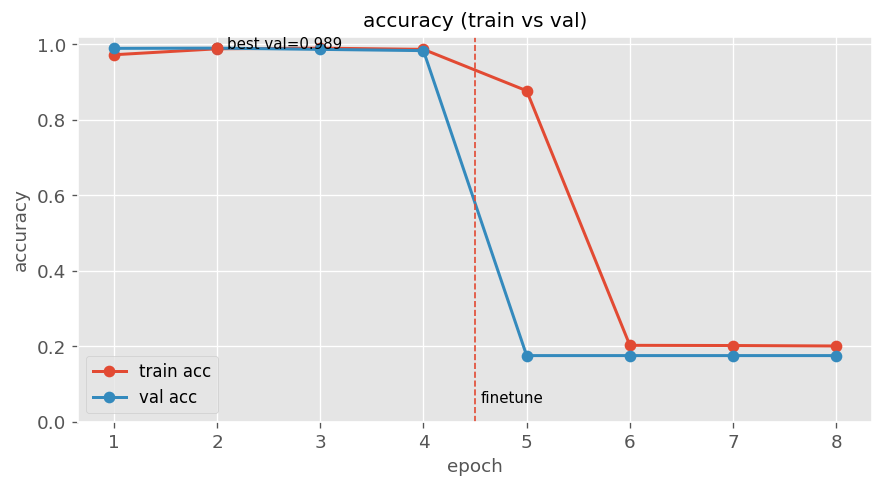

saved: /content/drive/MyDrive/ResiduosSDPA_EfficientNet_only11/part_11/curves_acc_pretty.png  | eval_acc_now: 0.9892


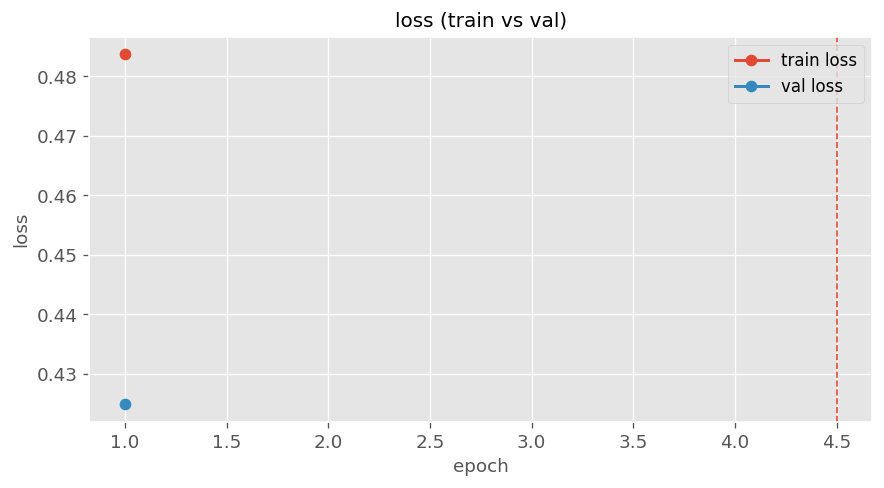

saved: /content/drive/MyDrive/ResiduosSDPA_EfficientNet_only11/part_11/curves_loss_pretty.png


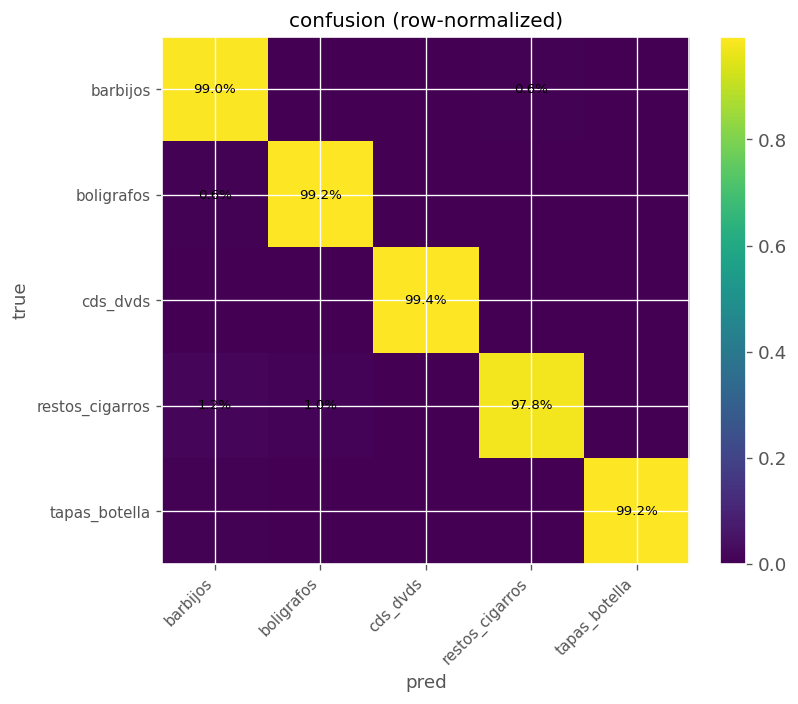

saved: /content/drive/MyDrive/ResiduosSDPA_EfficientNet_only11/part_11/confusion_eval_pretty.png


In [52]:
# pretty plots: LOSS, ACCURACY (train vs val) + CONFUSION MATRIX (row-normalized)
# uses history.csv and best.pt from part_11. Evaluates a fast, stratified subset by default.

import os, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import confusion_matrix, accuracy_score
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from pathlib import Path

# ---------- paths & basics ----------
outDir = workRoot / 'part_11'
ckpt = outDir / 'best.pt'
assert ckpt.exists(), f'checkpoint not found: {ckpt}'
classNames = json.loads((outDir / 'class_names.json').read_text())
numClasses = len(classNames)

# ---------- fallback defs if not in memory ----------
try:
    _ = valTf
except NameError:
    imgSize = 224
    meanEff = [0.485, 0.456, 0.406]
    stdEff  = [0.229, 0.224, 0.225]
    import torchvision.transforms as T
    valTf = T.Compose([
        T.Resize(int(imgSize*1.15)),
        T.CenterCrop(imgSize),
        T.ToTensor(),
        T.Normalize(meanEff, stdEff),
    ])

try:
    MappedImageDataset
except NameError:
    import os
    IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
    class MappedImageDataset(Dataset):
        def __init__(self, classDirs, classToIdx, transform=None):
            self.transform = transform
            self.files, self.labels = [], []
            for d in sorted(classDirs, key=lambda p: p.name):
                y = classToIdx[d.name]
                for root,_,fnames in os.walk(d):
                    for fn in fnames:
                        if os.path.splitext(fn)[1].lower() in IMG_EXTS:
                            self.files.append(os.path.join(root, fn))
                            self.labels.append(y)
        def __len__(self): return len(self.files)
        def __getitem__(self, idx):
            img = Image.open(self.files[idx]).convert('RGB')
            return (self.transform(img) if self.transform else img), self.labels[idx]

# ---------- build eval subset (fast & stratified) ----------
evalPerClass = 500    # set to None to evaluate ALL images (may take long)
evalBatchSize = 256
numWorkersEval = max(2, (os.cpu_count() or 2))

partPath = dataRoot / '11'
classDirs = sorted([p for p in partPath.iterdir() if p.is_dir()])
classToIdxTmp = {c.name:i for i,c in enumerate(classDirs)}
dsBase = MappedImageDataset(classDirs, classToIdxTmp, transform=valTf)

if evalPerClass is not None:
    byClass = {}
    for i, y in enumerate(dsBase.labels):
        byClass.setdefault(y, []).append(i)
    indices = []
    for y, idxs in byClass.items():
        random.shuffle(idxs)
        indices += idxs[:evalPerClass]
else:
    indices = list(range(len(dsBase)))

class IdxSubset(Dataset):
    def __init__(self, base, indices):
        self.base, self.indices = base, indices
        self.labels = [base.labels[i] for i in indices]
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        j = self.indices[i]; x,y = self.base[j]
        return x,y

dsEval = IdxSubset(dsBase, indices)
evalKw = dict(batch_size=evalBatchSize, shuffle=False, num_workers=numWorkersEval, pin_memory=True)
if numWorkersEval > 0:
    evalKw.update(dict(persistent_workers=True, prefetch_factor=2))
ldrEval = DataLoader(dsEval, **evalKw)

# ---------- load model ----------
modelEval = EffNetSDPA(numClasses=numClasses, freezeBackbone=False, extraDropout=0.0).to(device).eval()
modelEval.load_state_dict(torch.load(ckpt, map_location='cpu'))

# ---------- evaluate once and build confusion ----------
cm = np.zeros((numClasses, numClasses), dtype=np.int64)
yAll, pAll = [], []
with torch.no_grad(), torch.autocast(device_type='cuda', dtype=torch.float16, enabled=(device.type=='cuda')):
    for xb, yb in ldrEval:
        xb = xb.to(device, non_blocking=True)
        pred = torch.argmax(modelEval(xb), dim=1).cpu().numpy()
        y_np = yb.numpy()
        yAll.append(y_np); pAll.append(pred)
        for t,pr in zip(y_np, pred):
            cm[t,pr] += 1
y = np.concatenate(yAll) if yAll else np.array([])
p = np.concatenate(pAll) if pAll else np.array([])
valAccNow = accuracy_score(y, p) if y.size>0 else 0.0

# ---------- pretty style ----------
plt.style.use('ggplot')
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 120,
    "axes.grid": True,
})

# ---------- 1) ACCURACY curve (train vs val) ----------
histPath = outDir / 'history.csv'
df = pd.read_csv(histPath)
phaseOrder = {'frozen':0,'finetune':1}
df['phase_order'] = df['phase'].map(phaseOrder).fillna(99).astype(int)
df = df.sort_values(['phase_order','epoch']).reset_index(drop=True)
df['epoch_abs'] = np.arange(1, len(df)+1)
nFrozen = (df['phase']=='frozen').sum()
splitX = nFrozen if nFrozen>0 else None

# simple moving average for smoother curves (window=2)
def smooth(a, w=2):
    if w<=1 or len(a)<=w: return a
    return np.convolve(a, np.ones(w)/w, mode='valid')

x = df['epoch_abs'].values
accTr = df['train_acc'].values
accVa = df['val_acc'].values

plt.figure(figsize=(7.5,4.2))
plt.plot(x, accTr, marker='o', linewidth=1.8, label='train acc')
plt.plot(x, accVa, marker='o', linewidth=1.8, label='val acc')
if splitX is not None and splitX < x.max():
    plt.axvline(splitX+0.5, linestyle='--', linewidth=1)
    plt.text(splitX+0.55, 0.05, 'finetune', fontsize=9)
# annotate best val acc (from history) and current eval acc
bestIdx = int(np.argmax(accVa))
plt.scatter(x[bestIdx], accVa[bestIdx], s=45, zorder=3)
plt.text(x[bestIdx]+0.1, accVa[bestIdx], f"best val={accVa[bestIdx]:.3f}", fontsize=9)
plt.title('accuracy (train vs val)')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.ylim(0,1.02)
plt.legend(loc='lower left')
accFig = outDir / 'curves_acc_pretty.png'
plt.tight_layout(); plt.savefig(accFig); plt.show()
print('saved:', accFig, ' | eval_acc_now:', round(float(valAccNow),4))

# ---------- 2) LOSS curve (train vs val) ----------
lossTr = df['train_loss'].values
lossVa = df['val_loss'].values

plt.figure(figsize=(7.5,4.2))
plt.plot(x, lossTr, marker='o', linewidth=1.8, label='train loss')
plt.plot(x, lossVa, marker='o', linewidth=1.8, label='val loss')
if splitX is not None and splitX < x.max():
    plt.axvline(splitX+0.5, linestyle='--', linewidth=1)
    # ubicamos etiqueta arriba a la derecha
    ymax = max(np.max(lossTr), np.max(lossVa))
    plt.text(splitX+0.55, ymax*0.98, 'finetune', fontsize=9)
plt.title('loss (train vs val)')
plt.xlabel('epoch'); plt.ylabel('loss')
plt.legend(loc='upper right')
lossFig = outDir / 'curves_loss_pretty.png'
plt.tight_layout(); plt.savefig(lossFig); plt.show()
print('saved:', lossFig)

# ---------- 3) CONFUSION MATRIX (row-normalized + annotations) ----------
confNorm = cm.astype(np.float32) / (cm.sum(1, keepdims=True) + 1e-9)

fig, ax = plt.subplots(figsize=(7.5,6))
im = ax.imshow(confNorm, interpolation='nearest')
ax.set_title('confusion (row-normalized)')
ax.set_xlabel('pred'); ax.set_ylabel('true')
ticks = np.arange(numClasses)
ax.set_xticks(ticks); ax.set_yticks(ticks)
ax.set_xticklabels(classNames, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(classNames, fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# annotate cells (percentages)
for i in range(numClasses):
    for j in range(numClasses):
        val = confNorm[i, j]*100.0
        if val > 0.5:  # evita ruido visual
            ax.text(j, i, f"{val:.1f}%", ha='center', va='center', fontsize=8)

plt.tight_layout()
confFig = outDir / 'confusion_eval_pretty.png'
plt.savefig(confFig); plt.show()
print('saved:', confFig)


## Exportar/guardar el modelo para uso posterior
**Qué hace:**
- Guarda **`best_state_dict.pt`** (pesos) y **`model_traced_ts.pt`** (TorchScript) en `workRoot/part_11/`.  
- Mantiene **`class_names.json`** para mapear índices ↔ clases.

In [37]:
import torch, json

outDir = workRoot / 'part_11'
ckpt = outDir / 'best.pt'
classNames = json.loads((outDir / 'class_names.json').read_text())
numClasses = len(classNames)

# reconstruir y cargar pesos
modelExport = EffNetSDPA(numClasses=numClasses, freezeBackbone=False, extraDropout=0.0)
modelExport.load_state_dict(torch.load(ckpt, map_location='cpu'))
modelExport.eval()

# guardar state_dict con un nombre claro
bestStatePath = outDir / 'best_state_dict.pt'
torch.save(modelExport.state_dict(), bestStatePath)

# exportar TorchScript (trazado)
example = torch.randn(1, 3, imgSize, imgSize)
traced = torch.jit.trace(modelExport, example)
tsPath = outDir / 'model_traced_ts.pt'
traced.save(str(tsPath))

# ya tenias class_names.json; reiteramos ruta
clsPath = outDir / 'class_names.json'

print('export done:')
print('state_dict  ->', bestStatePath)
print('torchscript ->', tsPath)
print('class names ->', clsPath)


export done:
state_dict  -> /content/drive/MyDrive/ResiduosSDPA_EfficientNet_only11/part_11/best_state_dict.pt
torchscript -> /content/drive/MyDrive/ResiduosSDPA_EfficientNet_only11/part_11/model_traced_ts.pt
class names -> /content/drive/MyDrive/ResiduosSDPA_EfficientNet_only11/part_11/class_names.json


In [38]:
# single image inference (path or URL)
import torch, json, io, requests
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
from pathlib import Path

# config: adjust if needed
modelDir = workRoot / 'part_11'
classPath = modelDir / 'class_names.json'
tsPath = modelDir / 'model_traced_ts.pt'
stateDictPath = modelDir / 'best_state_dict.pt'
fallbackCkpt = modelDir / 'best.pt'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# define transforms if not already defined
try:
    _ = valTf
except NameError:
    meanEff = [0.485, 0.456, 0.406]
    stdEff  = [0.229, 0.224, 0.225]
    imgSize = 224
    valTf = T.Compose([
        T.Resize(int(imgSize*1.15)),
        T.CenterCrop(imgSize),
        T.ToTensor(),
        T.Normalize(meanEff, stdEff),
    ])

# load classes
classNames = json.loads(Path(classPath).read_text())
numClasses = len(classNames)

def loadImage(pathOrUrl):
    if str(pathOrUrl).lower().startswith('http'):
        r = requests.get(pathOrUrl, timeout=30)
        r.raise_for_status()
        img = Image.open(io.BytesIO(r.content)).convert('RGB')
    else:
        img = Image.open(pathOrUrl).convert('RGB')
    return img

def getModel():
    # try TorchScript first
    if Path(tsPath).exists():
        m = torch.jit.load(str(tsPath), map_location=device)
        m.eval()
        return m
    # else build model class and load weights
    m = EffNetSDPA(numClasses=numClasses, freezeBackbone=False, extraDropout=0.0)
    if Path(stateDictPath).exists():
        m.load_state_dict(torch.load(stateDictPath, map_location='cpu'))
    elif Path(fallbackCkpt).exists():
        m.load_state_dict(torch.load(fallbackCkpt, map_location='cpu'))
    else:
        raise FileNotFoundError("no model file found in modelDir")
    m.to(device).eval()
    return m

def predictImage(imgPath, topk=5, show=True):
    img = loadImage(imgPath)
    x = valTf(img).unsqueeze(0).to(device)
    m = getModel()
    with torch.no_grad(), torch.autocast(device_type='cuda', dtype=torch.float16, enabled=(device.type=='cuda')):
        logits = m(x)
        prob = torch.softmax(logits, dim=1).squeeze(0).cpu()
    topk = min(topk, numClasses)
    vals, idxs = torch.topk(prob, k=topk)
    preds = [(classNames[i], float(v)) for v, i in zip(vals.tolist(), idxs.tolist())]
    print("topk:", preds)
    if show:
        plt.figure(figsize=(6,3))
        plt.subplot(1,2,1)
        plt.imshow(img)
        plt.title('input')
        plt.axis('off')
        plt.subplot(1,2,2)
        labs = [p[0] for p in preds[::-1]]
        scores = [p[1] for p in preds[::-1]]
        plt.barh(labs, scores)
        plt.xlim(0, 1)
        plt.tight_layout()
        plt.show()
    return preds



topk: [('cds_dvds', 0.9355297684669495), ('barbijos', 0.019954539835453033), ('boligrafos', 0.01807148940861225), ('restos_cigarros', 0.013822106644511223), ('tapas_botella', 0.012622096575796604)]


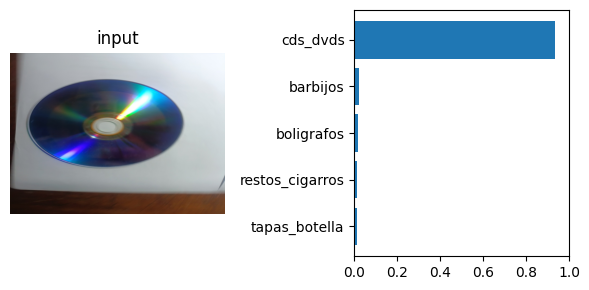

predicted: ('cds_dvds', 0.9355297684669495)


In [39]:
imgPath = "/content/MEGA_DATASET_LOCAL/11/cds_dvds/000020.jpg"
preds = predictImage(imgPath, topk=5, show=True)
print("predicted:", preds[0] if len(preds) else None)


topk: [('restos_cigarros', 0.9373566508293152), ('tapas_botella', 0.023490626364946365), ('cds_dvds', 0.016591394320130348), ('barbijos', 0.011503751389682293), ('boligrafos', 0.011057649739086628)]


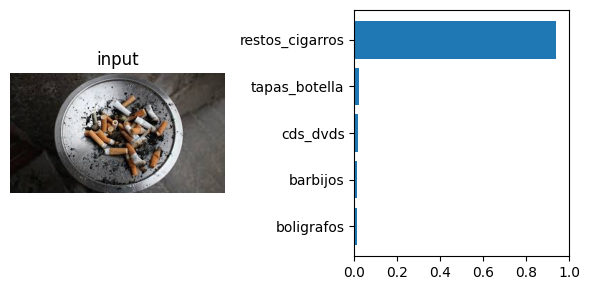

predicted: ('restos_cigarros', 0.9373566508293152)


In [40]:
imgPath = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTH5gA2csb4yoGC4OfNBixI36P3zvUMjj1x3w&s"  # <- set this
preds = predictImage(imgPath, topk=5, show=True)
print("predicted:", preds[0] if len(preds) else None)


topk: [('boligrafos', 0.9224540591239929), ('restos_cigarros', 0.02399553172290325), ('tapas_botella', 0.023525670170783997), ('cds_dvds', 0.022051816806197166), ('barbijos', 0.007973001338541508)]


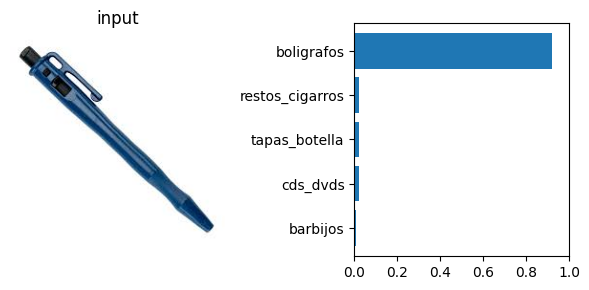

predicted: ('boligrafos', 0.9224540591239929)


In [41]:
imgPath = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQ-QjCLxk_3BctRcM1xpcSryo8LsMyiiEh8XQ&s"  # <- set this
preds = predictImage(imgPath, topk=5, show=True)
print("predicted:", preds[0] if len(preds) else None)

topk: [('barbijos', 0.8996745944023132), ('restos_cigarros', 0.03978794068098068), ('boligrafos', 0.02724752575159073), ('tapas_botella', 0.024400684982538223), ('cds_dvds', 0.00888927560299635)]


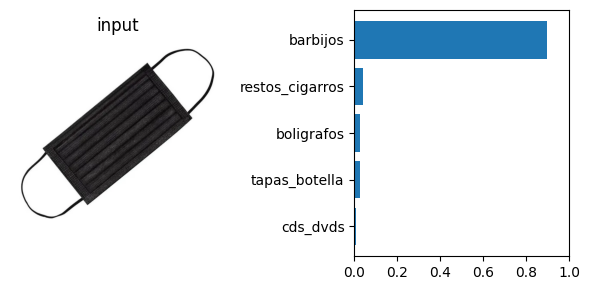

predicted: ('barbijos', 0.8996745944023132)


In [43]:
imgPath = "https://http2.mlstatic.com/D_NQ_NP_829534-MLA52180489829_102022-O.webp"  # <- set this
preds = predictImage(imgPath, topk=5, show=True)
print("predicted:", preds[0] if len(preds) else None)

topk: [('tapas_botella', 0.9225479960441589), ('boligrafos', 0.03485297039151192), ('restos_cigarros', 0.017163146287202835), ('cds_dvds', 0.014882504008710384), ('barbijos', 0.010553275234997272)]


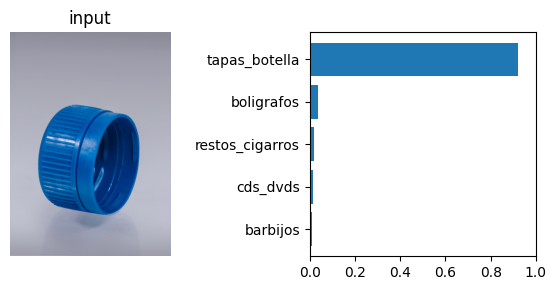

predicted: ('tapas_botella', 0.9225479960441589)


In [44]:
imgPath = "https://remsaplasticos.com/images/productos_img/foto_principal_58_1.jpg"  # <- set this
preds = predictImage(imgPath, topk=5, show=True)
print("predicted:", preds[0] if len(preds) else None)

topk: [('barbijos', 0.9277084469795227), ('cds_dvds', 0.02229142002761364), ('tapas_botella', 0.021012552082538605), ('boligrafos', 0.017789633944630623), ('restos_cigarros', 0.011197889223694801)]


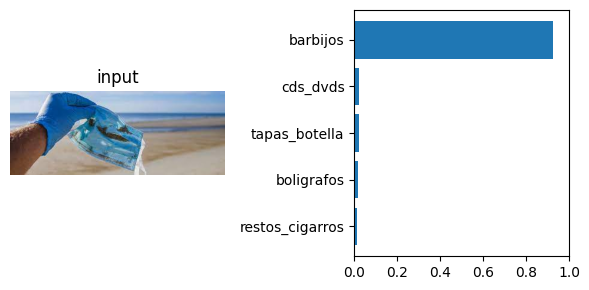

predicted: ('barbijos', 0.9277084469795227)


In [45]:
imgPath = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQHDv6mZe27jomG5zNDmcTTNhaspJQh6MnTUGa49STcJvEFkekW-XN8XUDY5RuJJJA8n3g&usqp=CAU"  # <- set this
preds = predictImage(imgPath, topk=5, show=True)
print("predicted:", preds[0] if len(preds) else None)